# Indian Institute of Information Technology Raichur

**Course:** Deep Learning for Medical Imaging  
**Name:** Shiva Prasad Rao
**Roll No:** CS23B1027

## Project
**Title:** Classification of the BUSI Dataset

In [2]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

In [3]:
import os
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
dataset_path="/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
image_files=[]
labels=[]
for class_name in ['benign','malignant','normal']:
    class_path=os.path.join(dataset_path,class_name)
    for filename in os.listdir(class_path):
        image_path=os.path.join(class_path,filename)
        image_files.append(image_path)
        labels.append(class_name)
label_encoder=LabelEncoder()
labels=label_encoder.fit_transform(labels)
labels=to_categorical(labels)

In [4]:
print(labels.shape)
print(len(image_files))

(1578, 3)
1578


In [5]:
X_train, X_test, y_train, y_test = train_test_split(image_files, labels, test_size=0.2, random_state=42, stratify=labels)


In [6]:
print(len(X_train),len(y_train))
print(len(X_test),len(y_test))

1262 1262
316 316


In [7]:
def load_preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((150, 150))
    image = image.convert('L')
    image = np.array(image)
    image = image.reshape((150, 150, 1))
    image = image.astype('float32') / 255.0
    return image

X_train = [str(image_path) for image_path in X_train]
X_test = [str(image_path) for image_path in X_test]

X_train = [load_preprocess_image(image_path) for image_path in X_train]
X_train = np.array(X_train)
y_train= np.array(y_train)

X_test= [load_preprocess_image(image_path) for image_path in X_test]
X_test = np.array(X_test)
y_test = np.array(y_test)

In [8]:
print(X_train.shape, y_train.shape)
print(X_test.shape,y_test.shape)

(1262, 150, 150, 1) (1262, 3)
(316, 150, 150, 1) (316, 3)


In [9]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3,activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,batch_size=32,epochs=20,validation_split=0.1)

Epoch 1/20
36/36 [==============================] - 35s 940ms/step - loss: 0.9286 - accuracy: 0.5181 - val_loss: 0.7942 - val_accuracy: 0.5827
Epoch 2/20
36/36 [==============================] - 33s 923ms/step - loss: 0.8410 - accuracy: 0.5859 - val_loss: 0.7345 - val_accuracy: 0.6299
Epoch 3/20
36/36 [==============================] - 33s 912ms/step - loss: 0.7642 - accuracy: 0.6714 - val_loss: 0.6789 - val_accuracy: 0.7087
Epoch 4/20
36/36 [==============================] - 33s 922ms/step - loss: 0.6830 - accuracy: 0.6978 - val_loss: 0.5802 - val_accuracy: 0.7323
Epoch 5/20
36/36 [==============================] - 33s 923ms/step - loss: 0.6296 - accuracy: 0.7075 - val_loss: 0.5442 - val_accuracy: 0.7480
Epoch 6/20
36/36 [==============================] - 33s 925ms/step - loss: 0.5707 - accuracy: 0.7480 - val_loss: 0.6883 - val_accuracy: 0.6378
Epoch 7/20
36/36 [==============================] - 34s 934ms/step - loss: 0.5143 - accuracy: 0.7674 - val_loss: 0.5182 - val_accuracy: 0.7402

In [10]:
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print('Training Accuracy:', train_accuracy,"Train loss",train_loss)
print('Testing Accuracy:', test_accuracy,"Test Loss",test_loss)

Training Accuracy: 0.9849445223808289 Train loss 0.08045569062232971
Testing Accuracy: 0.8322784900665283 Test Loss 0.9757587909698486


10/10 [==============================] - 2s 240ms/step
Confusion Matrix
 [[160  16   3]
 [ 22  61   1]
 [  6   5  42]]

Classification Report
               precision    recall  f1-score   support

      benign       0.85      0.89      0.87       179
   malignant       0.74      0.73      0.73        84
      normal       0.91      0.79      0.85        53

    accuracy                           0.83       316
   macro avg       0.84      0.80      0.82       316
weighted avg       0.83      0.83      0.83       316



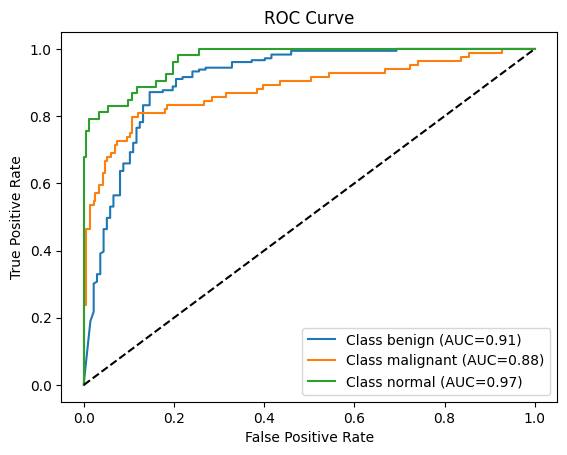

In [16]:
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

y_pred_prob=model.predict(X_test)
y_pred=np.argmax(y_pred_prob,axis=1)
y_true=np.argmax(y_test,axis=1)

cm=confusion_matrix(y_true,y_pred)
print("Confusion Matrix\n",cm)

print("\nClassification Report\n",classification_report(y_true,y_pred,target_names=label_encoder.classes_))

y_test_bin=label_binarize(y_true,classes=[0,1,2])
n_classes=3

fpr=dict()
tpr=dict()
roc_auc=dict()

for i in range(n_classes):
    fpr[i],tpr[i],_=roc_curve(y_test_bin[:,i],y_pred_prob[:,i])
    roc_auc[i]=auc(fpr[i],tpr[i])

plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i],tpr[i],label="Class %s (AUC=%0.2f)"%(label_encoder.classes_[i],roc_auc[i]))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [11]:
name = load_preprocess_image("/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (103).png")
name = np.expand_dims(name, axis=0) 
detect = model.predict(name)
print(detect)
predicted_class_index = np.argmax(detect[0])
predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]
print("Predicted Class Label:", predicted_class_label)



1/1 [==============================] - 0s 144ms/step
[[9.9999905e-01 9.6068754e-07 1.0921489e-11]]
Predicted Class Label: benign


In [12]:
model.save('/kaggle/working/breast_model')


In [13]:
!zip -r file.zip /kaggle/working



  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/breast_model/ (stored 0%)
  adding: kaggle/working/breast_model/saved_model.pb (deflated 89%)
  adding: kaggle/working/breast_model/keras_metadata.pb (deflated 93%)
  adding: kaggle/working/breast_model/assets/ (stored 0%)
  adding: kaggle/working/breast_model/fingerprint.pb (stored 0%)
  adding: kaggle/working/breast_model/variables/ (stored 0%)
  adding: kaggle/working/breast_model/variables/variables.index (deflated 66%)
  adding: kaggle/working/breast_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 65%)


In [14]:
!ls


breast_model  file.zip


In [15]:
from IPython.display import FileLink
FileLink(r'file.zip')

/kaggle/working/file.zip